# Statistics

## Measures of spread
range variance & standard deviation

Mean of array1: 50/5 = 10.0
Mean of array2: 50/5 = 10.0
range of array1: 30 - -10 = 40
range of array2: 12 - 8 = 4
variance of array1: 200.0 = 200.0
variance of array2: 2.0 = 2.0
standard deviation of array1: 14.142135623730951
standard deviation of array2: 1.4142135623730951


Text(0.5, 1.0, 'Histogram of Array 1 and Array 2')

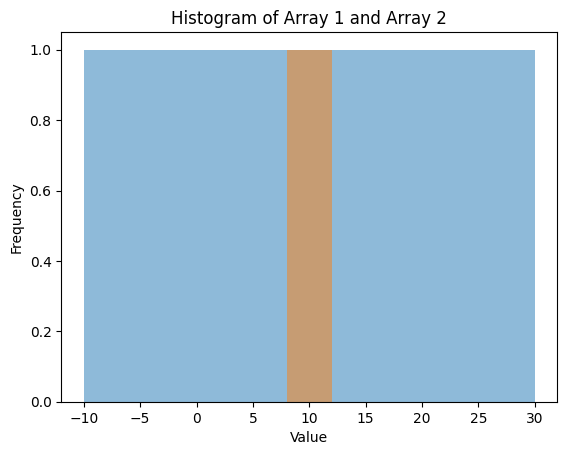

In [16]:
import numpy as np
import matplotlib.pyplot as plt

array1 = np.array([-10, 0, 10, 20, 30])
array2 = np.array([8,9,10,11,12])

print(f"Mean of array1: {array1[0]+array1[1]+array1[2]+array1[3]+array1[4]}/5 = {(array1[0]+array1[1]+array1[2]+array1[3]+array1[4])/5}")
print(f"Mean of array2: {array2[0]+array2[1]+array2[2]+array2[3]+array2[4]}/5 = {(array2[0]+array2[1]+array2[2]+array2[3]+array2[4])/5}")
mean1 = array1.mean()
mean2 = array2.mean()
print(f"range of array1: {array1.max()} - {array1.min()} = {array1.max() - array1.min()}")
print(f"range of array2: {array2.max()} - {array2.min()} = {array2.max() - array2.min()}")
print(f"variance of array1: {((array1[0]-mean1)**2 + (array1[1]-mean1)**2 + (array1[2]-mean1)**2 + (array1[3]-mean1)**2 + (array1[4]-mean1)**2)/5} = {array1.var()}")
print(f"variance of array2: {((array2[0]-mean2)**2 + (array2[1]-mean2)**2 + (array2[2]-mean2)**2 + (array2[3]-mean2)**2 + (array2[4]-mean2)**2)/5} = {array2.var()}")
print(f"standard deviation of array1: {variance1**0.5}")
print(f"standard deviation of array2: {variance2**0.5}")

variance1 = array1.var()
variance2 = array2.var()
deviation1 = array1.std()
deviation2 = array2.std()

plt.hist(array1, bins=5, alpha=0.5, label='Array 1')
plt.hist(array2, bins=5, alpha=0.5, label='Array 2')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Array 1 and Array 2')

### Parking lot example

In [24]:
# Parking lots example 
parking_lot = np.array([4, 4.2, 5, 4.3, 5.5]) #  meters
print(f"Mean: {parking_lot.mean()}m")
print(f"variance: {parking_lot.var()} m^2") # meter squared : variance is in the square of the units of the data
print(f"standard deviation: {parking_lot.std()}m") # standard deviation how far the data is from the mean [in meters]



Mean: 4.6m
variance: 0.31599999999999995 m^2
standard deviation: 0.5621387729022078m


### Sample variance

$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2$

$ \frac{1}{n-1}$ instead of  $\frac{1}{n}$, since use Sample variance to guess population variance


In [29]:
# TV survey example

tv_survey = np.array([1.5, 2.5, 4, 2, 1, 1]) # [hrs]
variance = tv_survey.var()
sample_variance = tv_survey.var(ddof=1) # sample variance
print(f"Population variance: {variance} hr^2")
print(f"Sample variance: {sample_variance} hr^2")



Population variance: 1.0833333333333333 hr^2
Sample variance: 1.3 hr^2


## Normal Distrubution - Bell curve


### Empirical Rule: 68–95–99.7 Rule

For a normal distribution, most data values fall within a certain number of standard deviations from the mean.

Let:

$$
X \sim N(\mu, \sigma^2)
$$

where:

- $\mu$ = mean
- $\sigma$ = standard deviation

68–95–99.7 Rule

$$
P(\mu - \sigma \leq X \leq \mu + \sigma) \approx 0.68
$$

$$
P(\mu - 2\sigma \leq X \leq \mu + 2\sigma) \approx 0.95
$$

$$
P(\mu - 3\sigma \leq X \leq \mu + 3\sigma) \approx 0.997
$$

In words:

| Range | Approximate Percentage |
|---|---:|
| Within $1\sigma$ of the mean | $68\%$ |
| Within $2\sigma$ of the mean | $95\%$ |
| Within $3\sigma$ of the mean | $99.7\%$ |

So:

$$
\mu \pm 1\sigma \Rightarrow 68\%
$$

$$
\mu \pm 2\sigma \Rightarrow 95\%
$$

$$
\mu \pm 3\sigma \Rightarrow 99.7\%
$$

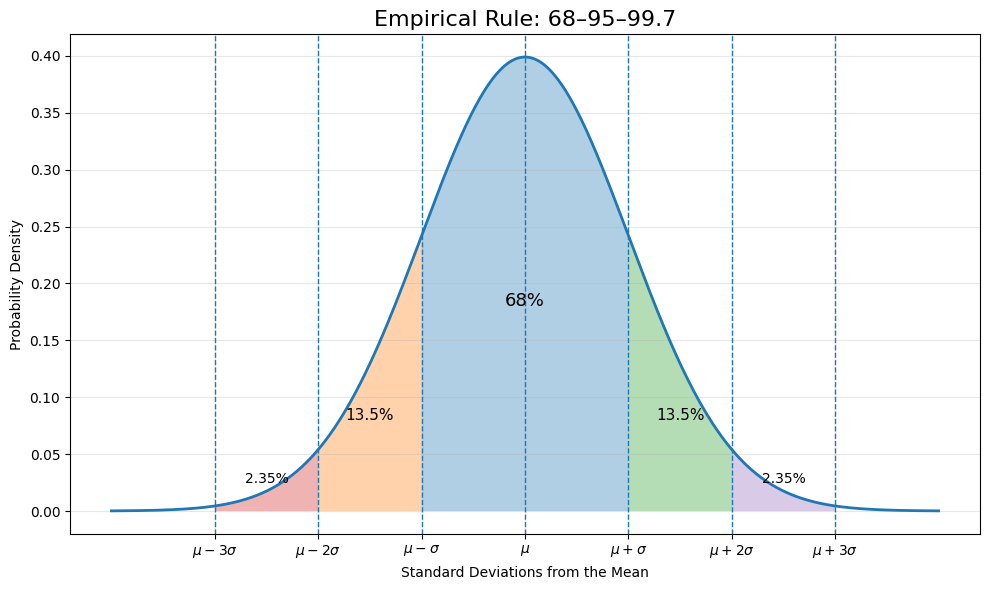

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0 # mean
sigma = 1 # standard deviation

# X values
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))

# Bell curve
plt.plot(x, y, linewidth=2)

# Shade regions
regions = [
    (mu - sigma, mu + sigma, "68%"),
    (mu - 2*sigma, mu - sigma, "13.5%"),
    (mu + sigma, mu + 2*sigma, "13.5%"),
    (mu - 3*sigma, mu - 2*sigma, "2.35%"),
    (mu + 2*sigma, mu + 3*sigma, "2.35%"),
]

for left, right, label in regions:
    x_fill = np.linspace(left, right, 300)
    y_fill = norm.pdf(x_fill, mu, sigma)
    plt.fill_between(x_fill, y_fill, alpha=0.35)

# Vertical lines for mean and standard deviations
for i in range(-3, 4):
    plt.axvline(mu + i*sigma, linestyle="--", linewidth=1)

# X-axis labels
tick_positions = [mu + i*sigma for i in range(-3, 4)]
tick_labels = [
    r"$\mu - 3\sigma$",
    r"$\mu - 2\sigma$",
    r"$\mu - \sigma$",
    r"$\mu$",
    r"$\mu + \sigma$",
    r"$\mu + 2\sigma$",
    r"$\mu + 3\sigma$",
]

plt.xticks(tick_positions, tick_labels)

# Percentage labels
plt.text(mu, 0.18, "68%", ha="center", fontsize=13)
plt.text(mu - 1.5*sigma, 0.08, "13.5%", ha="center", fontsize=11)
plt.text(mu + 1.5*sigma, 0.08, "13.5%", ha="center", fontsize=11)
plt.text(mu - 2.5*sigma, 0.025, "2.35%", ha="center", fontsize=10)
plt.text(mu + 2.5*sigma, 0.025, "2.35%", ha="center", fontsize=10)

# Title and labels
plt.title("Empirical Rule: 68–95–99.7", fontsize=16)
plt.xlabel("Standard Deviations from the Mean")
plt.ylabel("Probability Density")

# Clean layout
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Stable sensor mean: 1.9997811854664198
Stable sensor std: 0.02000741874201906
Noisy sensor mean: 1.9915189428132503
Noisy sensor std: 0.2514055678689165


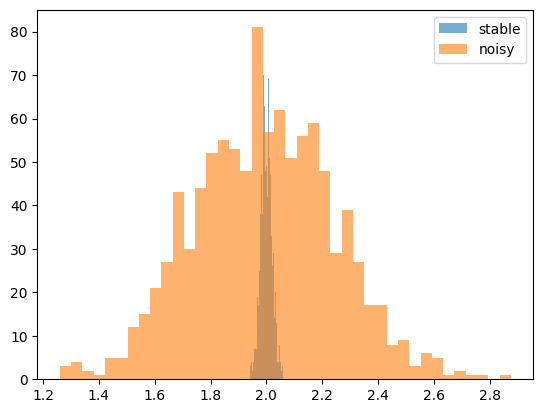

In [27]:
import numpy as np
import matplotlib.pyplot as plt

stable_sensor = np.random.normal(loc=2.0, scale=0.02, size=1000)
noisy_sensor = np.random.normal(loc=2.0, scale=0.25, size=1000)

print("Stable sensor mean:", stable_sensor.mean())
print("Stable sensor std:", stable_sensor.std())

print("Noisy sensor mean:", noisy_sensor.mean())
print("Noisy sensor std:", noisy_sensor.std())

plt.hist(stable_sensor, bins=40, alpha=0.6, label="stable")
plt.hist(noisy_sensor, bins=40, alpha=0.6, label="noisy")
plt.legend()
plt.show()

# z-Score

How many standard deviations a data point is from the mean

$$
z=\frac{x-\mu}{\sigma}
$$

where:
- $x$ = any data point
- $\mu$ = mean
- $\sigma$ = standard deviation
- $z$ = how many standard deviations the data point is from the mean

But. ***WHY***?

How **usual** & **unusual** a certain data point is:

| Z-score | Meaning |
|---|---|
| \|z\| ≈ 1 | Common / fairly normal |
| \|z\| ≈ 2 | Somewhat unusual |
| \|z\| ≥ 3 | Unusual / potential outlier |
| \|z\| ≥ 8 | Extremely abnormal |

NOTE: This is most meaningful when the data is roughly normally distributed.

In [42]:
# Cable example
cable_length = np.array([2,2,3,2,5,1,6]) # [m]
print(f"Mean: {cable_length.mean()}")
print(f"Standard Deviation: {cable_length.std()}")
z_scores = (cable_length - cable_length.mean()) / cable_length.std()
print(f"Z-scores: {z_scores}")

Mean: 3.0
Standard Deviation: 1.6903085094570331
Z-scores: [-0.59160798 -0.59160798  0.         -0.59160798  1.18321596 -1.18321596
  1.77482393]


In [49]:
# test performance example
test_a_mu = 151
test_a_sigma = 10

test_b_mu = 25.1
test_b_sigma = 6.4

student_testA_score = 172
student_testB_score = 37

z_score_a = (student_testA_score - test_a_mu) / test_a_sigma
z_score_b = (student_testB_score - test_b_mu) / test_b_sigma

print(f"Student's Z-score for Test A: {z_score_a}")
print(f"Student's Z-score for Test B: {z_score_b}")

print(f"Student's performance on Test A is {'above' if z_score_a > 0 else 'below'} average.")
print(f"Student's performance on Test B is {'above' if z_score_b > 0 else 'below'} average.")
print(f"Student performed better on Test {'A' if z_score_a > z_score_b else 'B'} based on Z-scores.")

Student's Z-score for Test A: 2.1
Student's Z-score for Test B: 1.8593749999999998
Student's performance on Test A is above average.
Student's performance on Test B is above average.
Student performed better on Test A based on Z-scores.


In [35]:
import numpy as np

readings = np.array([1.98, 2.01, 2.00, 2.03, 1.99, 2.02, 2.40])

mean = readings.mean()
std = readings.std()

z_scores = (readings - mean) / std

print("mean:", mean)
print("std:", std)

for value, z in zip(readings, z_scores):
    print(value, "z-score:", z)

mean: 2.0614285714285714
std: 0.13912261513074115
1.98 z-score: -0.585300753238778
2.01 z-score: -0.3696636336244927
2.0 z-score: -0.4415426734959201
2.03 z-score: -0.2259055538816348
1.99 z-score: -0.513421713367349
2.02 z-score: -0.29778459375306215
2.4 z-score: 2.4336189213612354


## Feature scaling

In [50]:
import numpy as np

height = np.array([160, 165, 170, 175, 180])
income = np.array([12000, 20000, 30000, 50000, 80000])

height_z = (height - height.mean()) / height.std()
income_z = (income - income.mean()) / income.std()

print("height mean:", height.mean())
print("height std:", height.std())
print("height z:", height_z)

print("income mean:", income.mean())
print("income std:", income.std())
print("income z:", income_z)

height mean: 170.0
height std: 7.0710678118654755
height z: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
income mean: 38400.0
income std: 24377.038376308145
income z: [-1.08298636 -0.75480867 -0.34458657  0.47585764  1.70652396]


In [51]:
# In ML Way
import numpy as np
from sklearn.preprocessing import StandardScaler

X = np.array([
    [160, 12000],
    [165, 20000],
    [170, 30000],
    [175, 50000],
    [180, 80000],
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)
print("mean:", X_scaled.mean(axis=0))
print("std:", X_scaled.std(axis=0))

[[-1.41421356 -1.08298636]
 [-0.70710678 -0.75480867]
 [ 0.         -0.34458657]
 [ 0.70710678  0.47585764]
 [ 1.41421356  1.70652396]]
mean: [0.0000000e+00 4.4408921e-17]
std: [1. 1.]


# p-Value
- PersonA using DrugA is cured and PersonB using DrugB is not cured
    - is DrugA better than DrugB?
        - surely not
    - Redo experiment to gain larger sample
